# 🚀 Employment Prediction Hackathon — R Starter Kit
Welcome! This notebook walks you from raw data to your submission, step by step.

**The goal:** for each person in Round 9, predict the *probability* that they are **employed (1)** vs **unemployed (0)**.
Your submissions are scored on **AUC**, so always submit a probability between 0 and 1 — never just a hard 0/1.

## 🛠️ Step 1: Load tools and data


In [26]:
# install.packages(c('scales','pROC'))  # uncomment on first run if needed
suppressMessages({
  library(dplyr)
  library(ggplot2)
  library(scales)
})

# Load the competition datasets (adjust the paths to match your Kaggle input folder)
data_dir <- '../../assets/dataset'
train_data <- read.csv(file.path(data_dir, 'train.csv'), stringsAsFactors = FALSE)
test_data  <- read.csv(file.path(data_dir, 'test.csv'),  stringsAsFactors = FALSE)

cat('Training rows:', nrow(train_data), '| columns:', ncol(train_data), '\n')
cat('Testing rows :', nrow(test_data),  '| columns:', ncol(test_data),  '\n')

# The target column in train_data is `employed_status` (1 = employed, 0 = unemployed).
# It is NOT present in test_data — that is what you predict.


Training rows: 16719 | columns: 33 
Testing rows : 3230 | columns: 32 


## Step 2: Get to know the data
Before modelling, look at what the data actually contains. Each chart below answers one question a
first-time viewer should ask, and ends with **what it means for your model**.

> **Sizing tip:** on Kaggle/Jupyter, control chart size with `options(repr.plot.width = ..., repr.plot.height = ...)`
> *before* the plot — not with fixed panel sizes. We set sensible sizes per chart below so nothing gets cropped.


In [27]:
# A tidy plotting frame with readable labels
plot_df <- train_data %>%
  filter(!is.na(employed_status)) %>%
  mutate(Status = factor(employed_status, levels = c(0, 1),
                         labels = c('Unemployed', 'Employed')))

pal <- c('Unemployed' = '#E15759', 'Employed' = '#59A14F')

# A reusable, clean theme
theme_hack <- theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = 'bold'),
        plot.subtitle = element_text(color = 'grey35'),
        legend.position = 'top')


### 2.1 — How many people are employed? (class balance)
The single most important thing to know before modelling: what fraction of the training set is employed?

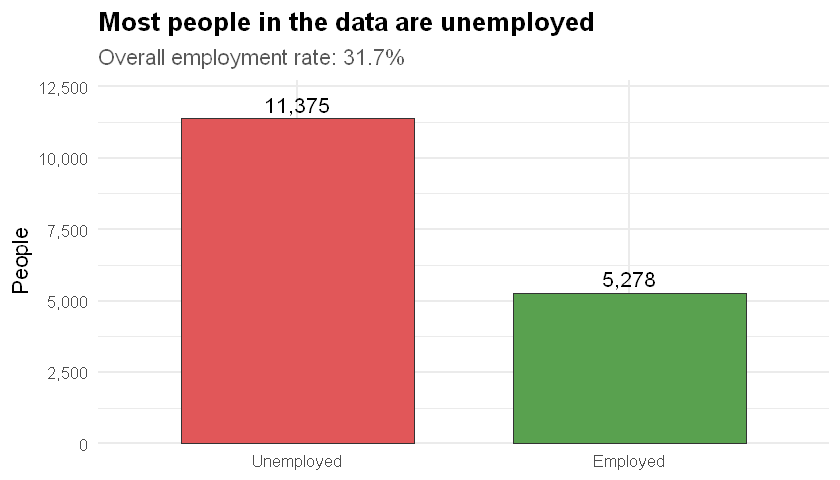

In [28]:
options(repr.plot.width = 7, repr.plot.height = 4)

rate <- mean(plot_df$Status == 'Employed')

ggplot(plot_df, aes(Status, fill = Status)) +
  geom_bar(color = 'grey20', width = 0.7) +
  geom_text(stat = 'count', aes(label = comma(after_stat(count))), vjust = -0.4, size = 4.5) +
  scale_fill_manual(values = pal) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = 'Most people in the data are unemployed',
       subtitle = sprintf('Overall employment rate: %.1f%%', 100 * rate),
       x = NULL, y = 'People') +
  theme_hack + theme(legend.position = 'none')


**What it means:** the classes are imbalanced (~1 in 3 employed). A model that predicts 'unemployed' for everyone would look ~68% 'accurate' but is useless — this is exactly why the competition uses **AUC**, which rewards ranking people by their probability of employment rather than raw accuracy.

### 2.2 — Who has history, and who is brand new?
Most of the 'lag' (previous-round) columns are missing. That is not dirty data — it is because many people appear for the *first* time in their row, so they have no earlier round to look back on.

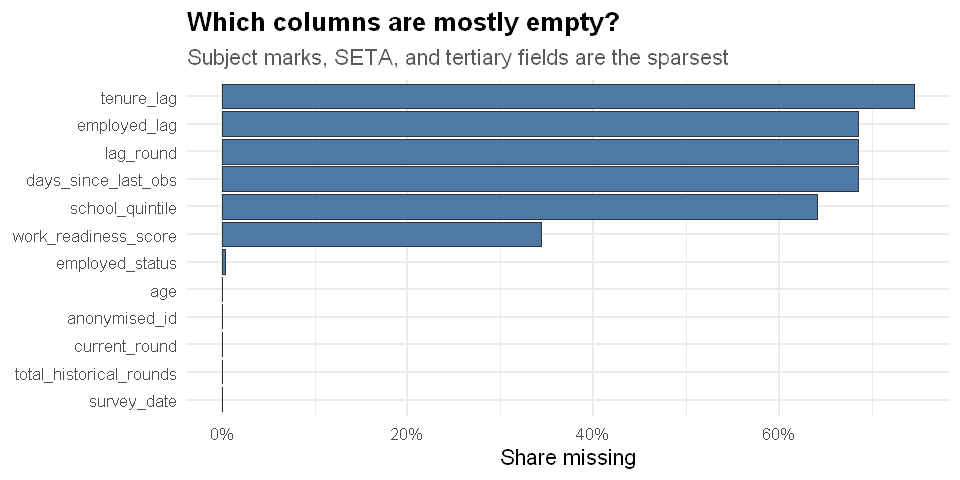

In [29]:
options(repr.plot.width = 8, repr.plot.height = 4)

miss <- train_data %>%
  summarise(across(everything(), ~ mean(is.na(.)))) %>%
  tidyr::pivot_longer(everything(), names_to = 'column', values_to = 'pct_missing') %>%
  arrange(desc(pct_missing)) %>%
  slice_head(n = 12) %>%
  mutate(column = factor(column, levels = rev(column)))   # lock labels to sorted bars

ggplot(miss, aes(column, pct_missing)) +
  geom_col(fill = '#4E79A7', color = 'grey20') +
  coord_flip() +
  scale_y_continuous(labels = percent) +
  labs(title = 'Which columns are mostly empty?',
       subtitle = 'Subject marks, SETA, and tertiary fields are the sparsest',
       x = NULL, y = 'Share missing') +
  theme_hack + theme(legend.position = 'none')


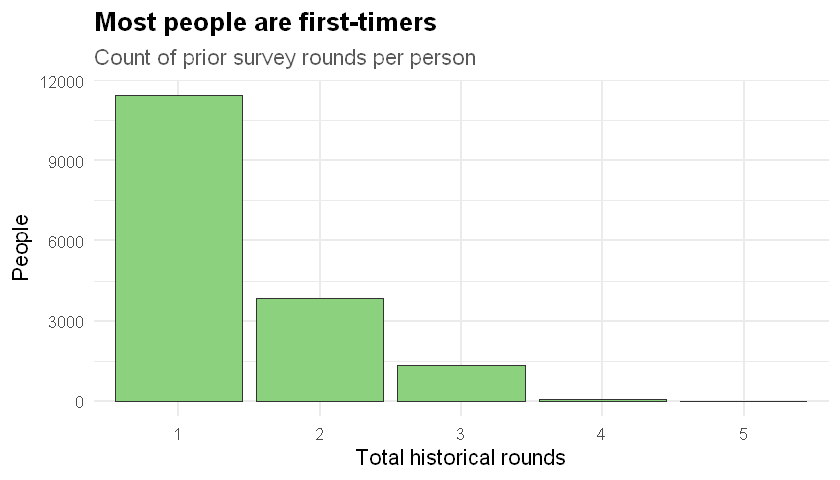

In [30]:
# How many prior observations does each person have?
options(repr.plot.width = 7, repr.plot.height = 4)

ggplot(train_data, aes(factor(total_historical_rounds))) +
  geom_bar(fill = '#8CD17D', color = 'grey20') +
  labs(title = 'Most people are first-timers',
       subtitle = 'Count of prior survey rounds per person',
       x = 'Total historical rounds', y = 'People') +
  theme_hack


**What it means:** the lag columns are powerful *when present* but empty for most people. Decide deliberately how to handle those NAs — dropping them throws away most of your data. A common trick (used in Step 5) is to treat 'missing history' as its own category rather than discarding the row.

### 2.3 — Does last round's status predict this round? (the key signal)
For people who *do* have history, their previous labour-market status is the strongest simple predictor there is.

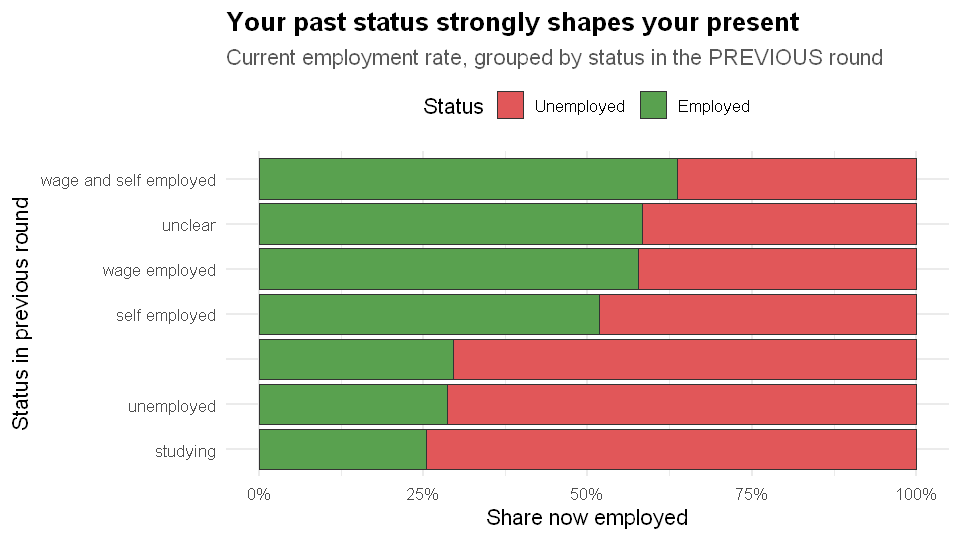

In [31]:
options(repr.plot.width = 8, repr.plot.height = 4.5)

hist_data <- plot_df %>% filter(!is.na(status_broad_lag))

ggplot(hist_data, aes(x = reorder(status_broad_lag, employed_status, mean), fill = Status)) +
  geom_bar(position = 'fill', color = 'grey20') +
  coord_flip() +
  scale_y_continuous(labels = percent) +
  scale_fill_manual(values = pal) +
  labs(title = 'Your past status strongly shapes your present',
       subtitle = 'Current employment rate, grouped by status in the PREVIOUS round',
       x = 'Status in previous round', y = 'Share now employed') +
  theme_hack


**What it means:** someone employed last round is more likely to be employed now than someone who was unemployed. This 'stickiness' is part of the story — but as you'll see, it is not the whole picture, and turning it into leaderboard gains takes care.

### 2.4 — The gender gap
A demographic split that is large and consistent in this data.

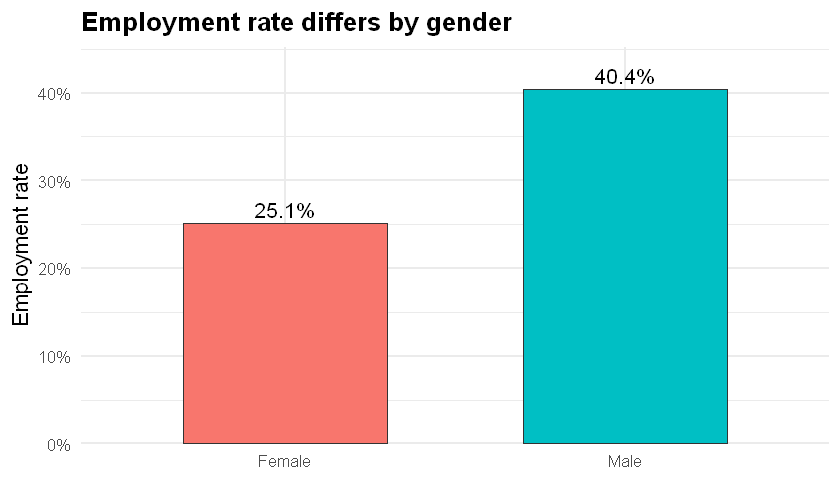

In [32]:
options(repr.plot.width = 7, repr.plot.height = 4)

gap <- plot_df %>% filter(!is.na(gender)) %>%
  group_by(gender) %>% summarise(rate = mean(employed_status), n = n())

ggplot(gap, aes(gender, rate, fill = gender)) +
  geom_col(color = 'grey20', width = 0.6) +
  geom_text(aes(label = percent(rate, accuracy = 0.1)), vjust = -0.4, size = 4.5) +
  scale_y_continuous(labels = percent, expand = expansion(mult = c(0, 0.12))) +
  labs(title = 'Employment rate differs by gender',
       x = NULL, y = 'Employment rate') +
  theme_hack + theme(legend.position = 'none')


### 2.5 — Does education move the needle?
Employment rate across the highest education levels present in the data.

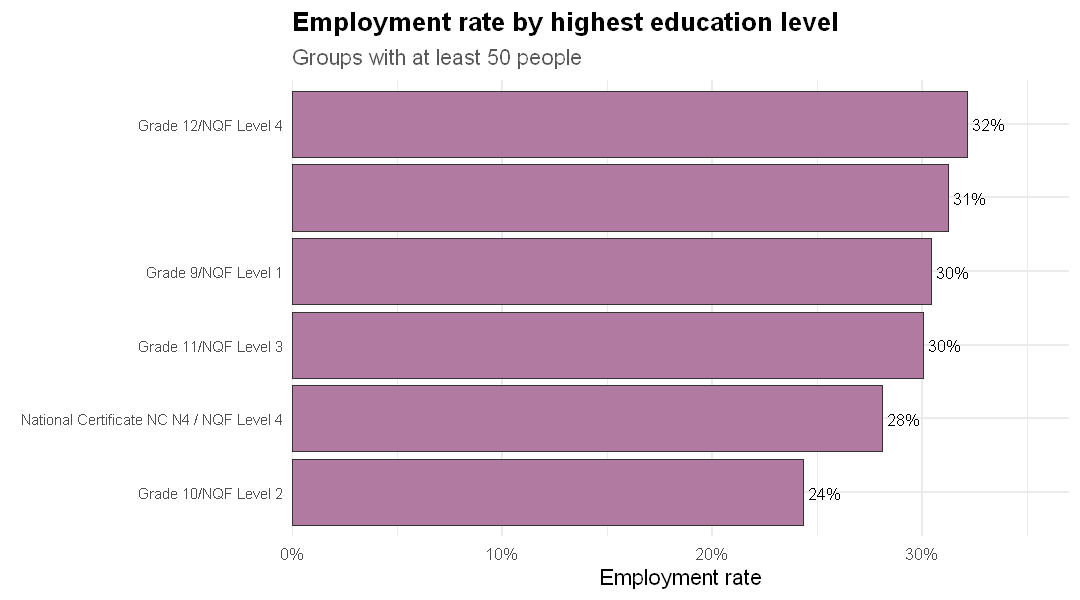

In [33]:
options(repr.plot.width = 9, repr.plot.height = 5)

edu <- plot_df %>% filter(!is.na(education_level)) %>%
  group_by(education_level) %>%
  summarise(rate = mean(employed_status), n = n()) %>%
  filter(n >= 50)   # ignore tiny, noisy groups

ggplot(edu, aes(reorder(education_level, rate), rate)) +
  geom_col(fill = '#B07AA1', color = 'grey20') +
  geom_text(aes(label = percent(rate, accuracy = 1)), hjust = -0.15, size = 3.5) +
  coord_flip() +
  scale_y_continuous(labels = percent, expand = expansion(mult = c(0, 0.15))) +
  labs(title = 'Employment rate by highest education level',
       subtitle = 'Groups with at least 50 people',
       x = NULL, y = 'Employment rate') +
  theme_hack + theme(axis.text.y = element_text(size = 9))


### 2.6 — Does the Work Readiness Score matter?
Harambee's behavioural assessment, compared between employed and unemployed people.

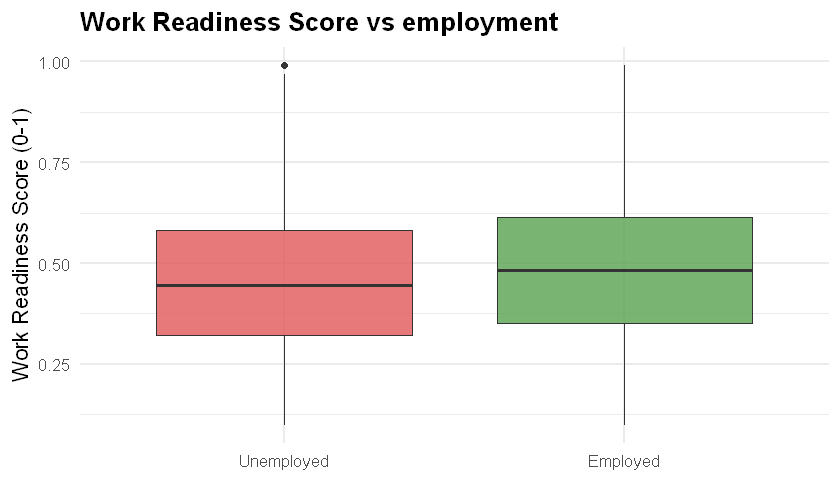

In [34]:
options(repr.plot.width = 7, repr.plot.height = 4)

score_data <- plot_df %>% filter(!is.na(work_readiness_score))

ggplot(score_data, aes(Status, work_readiness_score, fill = Status)) +
  geom_boxplot(color = 'grey20', alpha = 0.8, outlier.alpha = 0.15) +
  scale_fill_manual(values = pal) +
  labs(title = 'Work Readiness Score vs employment',
       x = NULL, y = 'Work Readiness Score (0-1)') +
  theme_hack + theme(legend.position = 'none')


**What it means:** if the boxes overlap heavily, the score alone is a weak separator — and adding weak features to a model can even *hurt* it. Part of the challenge is finding which combinations genuinely carry signal.

## 🏗️ Step 3: A first baseline model
We predict a binary outcome, so we start with **logistic regression**. For this first attempt we deliberately
pick two features that turn out to carry little signal: `work_readiness_score` and `sa_citizen`.
This sets a (low) floor — and shows that simply throwing variables at the model is not enough.

In [35]:
# Fill missing work readiness with the training median so every row has a value
wr_median <- median(train_data$work_readiness_score, na.rm = TRUE)
train_data$wr_filled <- ifelse(is.na(train_data$work_readiness_score), wr_median, train_data$work_readiness_score)
test_data$wr_filled  <- ifelse(is.na(test_data$work_readiness_score),  wr_median, test_data$work_readiness_score)

# Treat citizenship as a category
train_data$sa_citizen_chr <- as.character(train_data$sa_citizen)
test_data$sa_citizen_chr  <- as.character(test_data$sa_citizen)

baseline_model <- glm(employed_status ~ wr_filled + sa_citizen_chr,
                      data = train_data, family = binomial)

summary(baseline_model)



Call:
glm(formula = employed_status ~ wr_filled + sa_citizen_chr, family = binomial, 
    data = train_data)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -1.0516     0.5610  -1.875   0.0609 .  
wr_filled            0.9161     0.1061   8.632   <2e-16 ***
sa_citizen_chrTRUE  -0.1441     0.5586  -0.258   0.7964    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 20801  on 16652  degrees of freedom
Residual deviance: 20726  on 16650  degrees of freedom
  (66 observations deleted due to missingness)
AIC: 20732

Number of Fisher Scoring iterations: 4


Description of all the variables

In [36]:
variable_check <- data.frame(
  variable = names(train_data),
  type = sapply(train_data, function(x) class(x)[1]),
  unique_values = sapply(train_data, function(x) length(unique(x))),
  missing = sapply(train_data, function(x) sum(is.na(x))),
  missing_percent = sapply(train_data, function(x) mean(is.na(x)) * 100)
)

variable_check

,variable,type,unique_values,missing,missing_percent
,<chr>,<chr>,<int>,<int>,<dbl>
anonymised_id,anonymised_id,character,16719,0,0.00000000
lag_round,lag_round,integer,8,11449,68.47897602
current_round,current_round,integer,8,0,0.00000000
days_since_last_obs,days_since_last_obs,integer,287,11449,68.47897602
total_historical_rounds,total_historical_rounds,integer,5,0,0.00000000
survey_date,survey_date,character,204,0,0.00000000
sample,sample,character,24,0,0.00000000
sample_first,sample_first,character,23,0,0.00000000
employed_status,employed_status,integer,3,66,0.39476045


ANOVCA Table below

In [37]:
# ============================================================
# ANOVA ANALYSIS
# ============================================================

# Numeric variables to test
numeric_vars <- c(
  "age",
  "work_readiness_score",
  "wr_filled",
  "lag_round",
  "current_round",
  "days_since_last_obs",
  "total_historical_rounds",
  "employed_lag",
  "tenure_lag",
  "school_quintile"
)

# Make sure target is a factor
train_data$employed_status_factor <- factor(
  train_data$employed_status,
  levels = c(0, 1),
  labels = c("Unemployed", "Employed")
)

# Store results
anova_results <- data.frame(
  Variable = character(),
  F_statistic = numeric(),
  P_value = numeric(),
  Significance = character(),
  stringsAsFactors = FALSE
)

# Run ANOVA for every numeric variable
for (var in numeric_vars) {

  # Remove missing values
  temp <- train_data[
    !is.na(train_data[[var]]) &
    !is.na(train_data$employed_status_factor),
  ]

  # Create formula
  formula <- as.formula(
    paste(var, "~ employed_status_factor")
  )

  # Run ANOVA
  model <- aov(formula, data = temp)

  # Extract ANOVA table
  result <- summary(model)[[1]]

  f_value <- result[["F value"]][1]
  p_value <- result[["Pr(>F)"]][1]

  # Significance label
  significance <- if (p_value < 0.001) {
    "***"
  } else if (p_value < 0.01) {
    "**"
  } else if (p_value < 0.05) {
    "*"
  } else {
    "Not significant"
  }

  # Add result
  anova_results <- rbind(
    anova_results,
    data.frame(
      Variable = var,
      F_statistic = f_value,
      P_value = p_value,
      Significance = significance
    )
  )
}

# Sort by p-value
anova_results <- anova_results[
  order(anova_results$P_value),
]

# Display
anova_results

,Variable,F_statistic,P_value,Significance
,<chr>,<dbl>,<dbl>,<chr>
8,employed_lag,394.17613360,1.204886e-84,***
7,total_historical_rounds,79.58024798,5.102741e-19,***
2,work_readiness_score,77.11145925,1.856164e-18,***
3,wr_filled,75.31927440,4.369002e-18,***
1,age,48.72585686,3.054671e-12,***
9,tenure_lag,34.14281505,5.504593e-09,***
10,school_quintile,23.14193969,1.541559e-06,***
4,lag_round,0.86314388,3.529030e-01,Not significant
6,days_since_last_obs,0.13846546,7.098263e-01,Not significant


It appears that lag_round, day_since_last_obs, current_round are not significant and has no relationship with employment. This should be tested further.

Also to note that there is a huge F-statistic value and an extrememly low p-value for employed_lag as mention before that there is a high chance that someone who is employed will be employed in future.

## employed_lag
employed_lag
missing = 11,451 / 16,719

That's approximately 68.5% missing.

So we should rather make the variables into two parts.


employed_lag
employed_lag_missing

if (there no history):
    employ_lag_missing



In [38]:
    train_data$employed_lag_missing <- ifelse(
    is.na(train_data$employed_lag), 1, 0)

    
    test_data$employed_lag_missing <- ifelse(
    is.na(test_data$employed_lag), 1, 0)


  

employed_lag_missing is a new binary variable that indicates whether the employed_lag value is missing (1) or not (0). This can be useful for modeling, as it allows the model to account for the presence of missing data in the employed_lag variable.

## work_readiness_score and wr_filled

They're essentially measuring the same thing. Which can cause redudancy so we should make it so that wr_filled acts as a binary value where wr_missing will determine if something missing

In [39]:
train_data$wr_missing <- ifelse(
  is.na(train_data$work_readiness_score), 1, 0
)

test_data$wr_missing <- ifelse(
  is.na(test_data$work_readiness_score), 1, 0
)

## Investigation of the catergorical variables:

status_lag
status_broad_lag
education_level
education_field
institution_type
gender
province
race



In [40]:
# Chi-squared test for categorical variables
chisq.test(
  table(
    train_data$status_lag,
    train_data$employed_status
  )
)

# Chi-squared test for status_broad_lag vs employed_status
chisq.test(
  table(
    train_data$status_broad_lag,
    train_data$employed_status
  )
)

# Chi-squared test for education_level vs employed_status
chisq.test(
  table(
    train_data$education_level,
    train_data$employed_status
  )
)


	Pearson's Chi-squared test

data:  table(train_data$status_lag, train_data$employed_status)
X-squared = 485.05, df = 5, p-value < 2.2e-16



	Pearson's Chi-squared test

data:  table(train_data$status_broad_lag, train_data$employed_status)
X-squared = 471.29, df = 6, p-value < 2.2e-16


Warning message in chisq.test(table(train_data$education_level, train_data$employed_status)):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  table(train_data$education_level, train_data$employed_status)
X-squared = 44.366, df = 35, p-value = 0.1333


## Conclusion of the chi-squared test 
| Variable | χ² | df | p-value | Result |
|---|---:|---:|---:|---|
| status_lag | 485.05 | 5 | < 2.2e-16 | Extremely strong |
| status_broad_lag | 471.29 | 6 | < 2.2e-16 | Extremely strong |
| education_level | 44.37 | 35 | 0.1333 | Not significant |


**education_level**
We don't have enough evidence to say education level is associated with employment status in this dataset.

However, I wouldn't immediately remove it. As the p-value is not too high above 0.1 so it still play a factor as logically education still a deciding factor especially NQF levels.

In [ ]:
table(
  train_data$education_level,
  train_data$employed_status
)


                                                                                                                             
                                                                                                                        3136 
                                                                                            Advanced Certificate NQF Level 6 
                                                                                                                           2 
                                                                                                Advanced Diploma NQF Level 7 
                                                                                                                           1 
                                                                            Bachelor of Technology Degree B Tech NQF Level 7 
                                                                                                                     

                                                                                                                              
                                                                                                                                  0
                                                                                                                               2147
  Advanced Certificate NQF Level 6                                                                                                2
  Advanced Diploma NQF Level 7                                                                                                    0
  Bachelor of Technology Degree B Tech NQF Level 7                                                                                1
  Bachelors Degree NQF Level 7                                                                                                   28
  Diploma NQF Level 5                                                            

Appear categories are extremely imbalanced. We can standardise the edcuation value.

## Convert Education into NQF Level

| Education   | NQF |
| ----------- | --: |
| Grade 9     |   1 |
| Grade 10    |   2 |
| Grade 11    |   3 |
| Grade 12    |   4 |
| Certificate | 5–6 |
| Diploma     | 5–6 |
| Bachelor's  |   7 |
| Honours     |   8 |

Then you have:

**education_nqf** instead of 36 separate categories.



## 2. Standardise it

In [48]:
# ============================================================
# EDUCATION FEATURE ENGINEERING
# ============================================================

# Convert education_level to character
train_data$education_level <- as.character(train_data$education_level)
test_data$education_level  <- as.character(test_data$education_level)


# ------------------------------------------------------------
# 1. Extract NQF level from education_level
# ------------------------------------------------------------

extract_nqf <- function(x) {
  
  # Start with missing values
  result <- rep(NA_real_, length(x))
  
  # Extract "NQF Level X"
  matches <- regmatches(
    x,
    regexpr("NQF Level [0-9]+", x, ignore.case = TRUE)
  )
  
  # Convert extracted text to numbers
  valid <- matches != ""
  
  result[valid] <- as.numeric(
    sub(".*NQF Level ", "", matches[valid], ignore.case = TRUE)
  )
  
  result
}


train_data$education_nqf <- extract_nqf(
  train_data$education_level
)

test_data$education_nqf <- extract_nqf(
  test_data$education_level
)


# ------------------------------------------------------------
# 2. Check the extracted values
# ------------------------------------------------------------

cat("Training NQF distribution:\n")
print(table(train_data$education_nqf, useNA = "ifany"))

cat("\nTesting NQF distribution:\n")
print(table(test_data$education_nqf, useNA = "ifany"))


# ------------------------------------------------------------
# 3. Calculate training statistics
# ------------------------------------------------------------

edu_mean <- mean(
  train_data$education_nqf,
  na.rm = TRUE
)

edu_sd <- sd(
  train_data$education_nqf,
  na.rm = TRUE
)


# ------------------------------------------------------------
# 4. Standardise using TRAINING statistics
# ------------------------------------------------------------

train_data$education_nqf_scaled <-
  (train_data$education_nqf - edu_mean) / edu_sd

test_data$education_nqf_scaled <-
  (test_data$education_nqf - edu_mean) / edu_sd


# ------------------------------------------------------------
# 5. Check result
# ------------------------------------------------------------

summary(train_data$education_nqf)

summary(train_data$education_nqf_scaled)

summary(test_data$education_nqf_scaled)

Warning message in result[valid] <- as.numeric(sub(".*NQF Level ", "", matches[valid], :
"number of items to replace is not a multiple of replacement length"
Warning message in result[valid] <- as.numeric(sub(".*NQF Level ", "", matches[valid], :
"number of items to replace is not a multiple of replacement length"


Training NQF distribution:

    1     2     3     4     5     6     7     8 
  180   409  1299 14534    95   140    57     5 

Testing NQF distribution:

   1    2    3    4    5    6    7 
  50   79  256 2681   54   72   38 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   4.000   4.000   3.875   4.000   8.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-4.9935  0.2172  0.2172  0.0000  0.2172  7.1649 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-4.99352  0.21723  0.21723  0.08172  0.21723  5.42798 

## Education Level Feature Engineering

The original `education_level` variable contains a large number of categorical education levels, ranging from Grade 9/NQF Level 1 through postgraduate qualifications. Many of these categories have very small sample sizes, which can make direct categorical modelling and statistical testing less reliable.

To address this, the education information was transformed into an ordinal **NQF level** ranging from 1 to 8. This provides the models with an explicit representation of increasing educational attainment.

### NQF Distribution

The resulting distribution in the training data was:

- **NQF 1:** 180 observations
- **NQF 2:** 409 observations
- **NQF 3:** 1,299 observations
- **NQF 4:** 14,534 observations
- **NQF 5:** 95 observations
- **NQF 6:** 140 observations
- **NQF 7:** 57 observations
- **NQF 8:** 5 observations

The data is heavily concentrated around **NQF Level 4**, which corresponds primarily to Grade 12/Matric qualifications.

The test dataset follows a similar distribution, with NQF Level 4 also being the dominant category.

### Standardisation

The NQF variable was also standardised using the mean and standard deviation calculated from the training data:

$$
z = \frac{x-\mu_{train}}{\sigma_{train}}
$$

The training statistics were then applied to both the training and test datasets to avoid data leakage.

The standardised training variable has a mean approximately equal to 0, allowing it to be used effectively in models where feature scaling is beneficial.

### Interpretation

The NQF transformation provides a more meaningful representation of education than treating every qualification as an unrelated category. It captures the natural ordering of educational attainment while reducing the number of individual categories.

However, the strong concentration at NQF Level 4 and the very small number of observations at higher levels should be considered when interpreting the model. Education should therefore be evaluated alongside other predictors such as previous employment status, work readiness, age, tenure, and employment history.

The standardised NQF variable will be compared against the original categorical education variable during model evaluation to determine which representation provides better predictive performance.

## XGBoost with carefully prepared numeric + categorical features.

In [ ]:
# install.packages("xgboost") #uncomment if error for xgboost not found

# ============================================================
# FINAL PREDICTIVE MODEL
# Employment Status Prediction
# ============================================================

library(xgboost)

set.seed(42)

# ------------------------------------------------------------
# 1. REMOVE ROWS WITH MISSING TARGET
# ------------------------------------------------------------

train_model <- train_data[
  !is.na(train_data$employed_status),
]

# ------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ------------------------------------------------------------

# Work readiness
wr_median <- median(
  train_model$work_readiness_score,
  na.rm = TRUE
)

train_model$wr_filled <- ifelse(
  is.na(train_model$work_readiness_score),
  wr_median,
  train_model$work_readiness_score
)

test_data$wr_filled <- ifelse(
  is.na(test_data$work_readiness_score),
  wr_median,
  test_data$work_readiness_score
)


# ------------------------------------------------------------
# Education NQF
# ------------------------------------------------------------

extract_nqf <- function(x) {

  result <- rep(NA_real_, length(x))

  pattern <- "NQF Level [0-9]+"

  has_nqf <- grepl(
    pattern,
    x,
    ignore.case = TRUE
  )

  extracted <- regmatches(
    x,
    regexpr(
      pattern,
      x,
      ignore.case = TRUE
    )
  )

  result[has_nqf] <- as.numeric(
    sub(
      ".*NQF Level ",
      "",
      extracted[has_nqf],
      ignore.case = TRUE
    )
  )

  result
}


train_model$education_nqf <- extract_nqf(
  as.character(train_model$education_level)
)

test_data$education_nqf <- extract_nqf(
  as.character(test_data$education_level)
)


# Missing education NQF
edu_median <- median(
  train_model$education_nqf,
  na.rm = TRUE
)

train_model$education_nqf <- ifelse(
  is.na(train_model$education_nqf),
  edu_median,
  train_model$education_nqf
)

test_data$education_nqf <- ifelse(
  is.na(test_data$education_nqf),
  edu_median,
  test_data$education_nqf
)


# ------------------------------------------------------------
# 3. ADD TEMPORAL / HISTORY FEATURES
# ------------------------------------------------------------

# Whether the person has previous employment information
train_model$has_employment_history <-
  !is.na(train_model$employed_lag)

test_data$has_employment_history <-
  !is.na(test_data$employed_lag)


# Whether previous status information exists
train_model$has_status_history <-
  !is.na(train_model$status_lag)

test_data$has_status_history <-
  !is.na(test_data$status_lag)


# Number of historical observations
train_model$historical_rounds_filled <-
  ifelse(
    is.na(train_model$total_historical_rounds),
    0,
    train_model$total_historical_rounds
  )

test_data$historical_rounds_filled <-
  ifelse(
    is.na(test_data$total_historical_rounds),
    0,
    test_data$total_historical_rounds
  )


# ------------------------------------------------------------
# 4. SELECT FEATURES
# ------------------------------------------------------------

features <- c(

  # Employment history
  "employed_lag",
  "status_lag",
  "status_broad_lag",
  "tenure_lag",

  # Historical information
  "lag_round",
  "current_round",
  "days_since_last_obs",
  "total_historical_rounds",
  "historical_rounds_filled",
  "has_employment_history",
  "has_status_history",

  # Demographics
  "age",
  "gender",
  "race",
  "sa_citizen",
  "province",
  "district",
  "municipality",

  # Education
  "education_level",
  "education_nqf",
  "education_schooling_grade_twelve_equiv",
  "institution_type",
  "school_quintile",
  "education_field",

  # Work readiness
  "wr_filled"
)


# Keep only features that actually exist
features <- features[
  features %in% names(train_model)
]


# ------------------------------------------------------------
# 5. COMBINE TRAIN + TEST FOR CONSISTENT ENCODING
# ------------------------------------------------------------

X_train_raw <- train_model[, features, drop = FALSE]
X_test_raw  <- test_data[, features, drop = FALSE]

combined <- rbind(
  X_train_raw,
  X_test_raw
)


# ------------------------------------------------------------
# 6. CONVERT CATEGORICAL VARIABLES TO NUMERIC
# ------------------------------------------------------------

for (col in names(combined)) {

  if (
    is.character(combined[[col]]) ||
    is.factor(combined[[col]]) ||
    is.logical(combined[[col]])
  ) {

    combined[[col]] <- as.factor(
      combined[[col]]
    )

    combined[[col]] <- as.numeric(
      combined[[col]]
    )
  }
}


# ------------------------------------------------------------
# 7. HANDLE INFINITE / MISSING VALUES
# ------------------------------------------------------------

for (col in names(combined)) {

  combined[[col]][
    !is.finite(combined[[col]])
  ] <- NA

  median_value <- median(
    combined[[col]],
    na.rm = TRUE
  )

  if (!is.finite(median_value)) {
    median_value <- 0
  }

  combined[[col]][
    is.na(combined[[col]])
  ] <- median_value
}


# Split back
X_train <- combined[
  1:nrow(X_train_raw),
  ,
  drop = FALSE
]

X_test <- combined[
  (nrow(X_train_raw) + 1):nrow(combined),
  ,
  drop = FALSE
]


# ------------------------------------------------------------
# 8. CLEAN TARGET
# ------------------------------------------------------------

y <- as.numeric(
  train_model$employed_status
)

# Make sure target is binary
y <- ifelse(
  y > 0,
  1,
  0
)


# ------------------------------------------------------------
# 9. CREATE XGBOOST MATRICES
# ------------------------------------------------------------

dtrain <- xgb.DMatrix(
  data = as.matrix(X_train),
  label = y
)

dtest <- xgb.DMatrix(
  data = as.matrix(X_test)
)


# ------------------------------------------------------------
# 10. TRAIN MODEL
# ------------------------------------------------------------

params <- list(

  objective = "binary:logistic",

  eval_metric = "logloss",

  eta = 0.03,

  max_depth = 5,

  min_child_weight = 5,

  subsample = 0.85,

  colsample_bytree = 0.85,

  gamma = 0.1,

  lambda = 2,

  alpha = 0.1
)


final_model <- xgb.train(

  params = params,

  data = dtrain,

  nrounds = 500,

  verbose = 0
)


# ------------------------------------------------------------
# 11. PREDICT TEST PROBABILITIES
# ------------------------------------------------------------

test_prob <- predict(
  final_model,
  dtest
)


# ------------------------------------------------------------
# 12. SAFETY CHECK
# ------------------------------------------------------------

test_prob <- pmin(
  pmax(test_prob, 0),
  1
)


# ------------------------------------------------------------
# 13. CREATE SUBMISSION
# ------------------------------------------------------------

submission_final <- data.frame(

  anonymised_id =
    test_data$anonymised_id,

  employed_status =
    test_prob
)


# ------------------------------------------------------------
# 14. SAVE SUBMISSION
# ------------------------------------------------------------

write.csv(
  submission_final,
  "submission_xgboost_final.csv",
  row.names = FALSE,
  quote = FALSE
)


# ------------------------------------------------------------
# 15. CHECK OUTPUT
# ------------------------------------------------------------

cat(
  "Saved submission_xgboost_final.csv\n"
)

cat(
  "Rows:",
  nrow(submission_final),
  "\n"
)

cat(
  "Minimum probability:",
  min(submission_final$employed_status),
  "\n"
)

cat(
  "Maximum probability:",
  max(submission_final$employed_status),
  "\n"
)

cat(
  "Mean probability:",
  mean(submission_final$employed_status),
  "\n"
)

head(
  submission_final,
  10
)

Installing package into 'C:/Users/27823/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'xgboost' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\27823\AppData\Local\Temp\RtmpIjH9ZF\downloaded_packages


Warning message:
"package 'xgboost' was built under R version 4.4.3"


Saved submission_xgboost_final.csv
Rows: 3230 
Minimum probability: 0.03969123 
Maximum probability: 0.8062769 
Mean probability: 0.3477222 


,anonymised_id,employed_status
,<chr>,<dbl>
1,ID_10,0.3050941
2,ID_100,0.3120655
3,ID_1000,0.3106237
4,ID_1001,0.3106237
5,ID_1002,0.3106237
6,ID_1003,0.3106237
7,ID_1004,0.3106237
8,ID_1005,0.3106237
9,ID_1006,0.3106237


# Previous employment → current employment Test

previous labour-market status
previous broad status
previous tenure
participant history
time since previous observation
education level converted to NQF
work-readiness
demographics
missingness as information

The important part is that we're treating the missing _lag values as meaningful rather than simply throwing those rows/features away



In [53]:
# ============================================================
# PREDICTIVE INSIGHTS — ROUND 9 EMPLOYMENT MODEL
# Historical + Missingness + Demographic Features
# ============================================================

# ------------------------------------------------------------
# 1. Packages
# ------------------------------------------------------------

required_packages <- c(
  "dplyr",
  "rpart",
  "rpart.plot"
)

for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
}

library(dplyr)
library(rpart)
library(rpart.plot)


# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

data_dir <- "../../assets/dataset"

train_data <- read.csv(
  file.path(data_dir, "train.csv"),
  stringsAsFactors = FALSE
)

test_data <- read.csv(
  file.path(data_dir, "test.csv"),
  stringsAsFactors = FALSE
)

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows :", nrow(test_data), "\n")


# ------------------------------------------------------------
# 3. Clean target
# ------------------------------------------------------------

train_data$employed_status <- as.numeric(
  as.character(train_data$employed_status)
)

# Remove rows where the target is unavailable
train_data <- train_data[
  !is.na(train_data$employed_status),
]

train_data$employed_status <- ifelse(
  train_data$employed_status > 0,
  1,
  0
)

cat("\nTarget distribution:\n")
print(table(train_data$employed_status))


# ------------------------------------------------------------
# 4. Helper function
# ------------------------------------------------------------

safe_numeric <- function(x) {
  suppressWarnings(as.numeric(as.character(x)))
}


# ------------------------------------------------------------
# 5. Create NQF education feature
# ------------------------------------------------------------

extract_nqf <- function(x) {

  x <- as.character(x)

  # Look for "NQF Level X"
  result <- suppressWarnings(
    as.numeric(
      sub(
        ".*NQF Level ([0-9]+).*",
        "\\1",
        x
      )
    )
  )

  # Invalid matches become NA
  result[!grepl("NQF Level [0-9]+", x)] <- NA

  result
}

train_data$education_nqf <- extract_nqf(
  train_data$education_level
)

test_data$education_nqf <- extract_nqf(
  test_data$education_level
)


# ------------------------------------------------------------
# 6. Missingness indicators
# ------------------------------------------------------------

missing_features <- c(
  "employed_lag",
  "status_lag",
  "status_broad_lag",
  "tenure_lag",
  "days_since_last_obs",
  "lag_round",
  "work_readiness_score",
  "school_quintile"
)

for (feature in missing_features) {

  if (feature %in% names(train_data)) {

    train_data[[paste0(feature, "_missing")]] <-
      as.integer(is.na(train_data[[feature]]))

    test_data[[paste0(feature, "_missing")]] <-
      as.integer(is.na(test_data[[feature]]))
  }
}


# ------------------------------------------------------------
# 7. Historical / timeline features
# ------------------------------------------------------------

train_data$round_gap <- safe_numeric(
  train_data$current_round
) - safe_numeric(
  train_data$lag_round
)

test_data$round_gap <- safe_numeric(
  test_data$current_round
) - safe_numeric(
  test_data$lag_round
)

# Whether participant has previous observed history
train_data$has_history <- as.integer(
  !is.na(train_data$lag_round)
)

test_data$has_history <- as.integer(
  !is.na(test_data$lag_round)
)


# ------------------------------------------------------------
# 8. Clean important numeric variables
# ------------------------------------------------------------

numeric_features <- c(
  "age",
  "lag_round",
  "current_round",
  "days_since_last_obs",
  "total_historical_rounds",
  "employed_lag",
  "tenure_lag",
  "school_quintile",
  "work_readiness_score",
  "education_nqf",
  "round_gap"
)

for (feature in numeric_features) {

  if (feature %in% names(train_data)) {
    train_data[[feature]] <-
      safe_numeric(train_data[[feature]])
  }

  if (feature %in% names(test_data)) {
    test_data[[feature]] <-
      safe_numeric(test_data[[feature]])
  }
}


# ------------------------------------------------------------
# 9. Median imputation
# ------------------------------------------------------------

for (feature in numeric_features) {

  if (feature %in% names(train_data)) {

    median_value <- median(
      train_data[[feature]],
      na.rm = TRUE
    )

    if (!is.finite(median_value)) {
      median_value <- 0
    }

    train_data[[feature]][
      is.na(train_data[[feature]])
    ] <- median_value

    test_data[[feature]][
      is.na(test_data[[feature]])
    ] <- median_value
  }
}


# ------------------------------------------------------------
# 10. Work readiness
# ------------------------------------------------------------

wr_median <- median(
  train_data$work_readiness_score,
  na.rm = TRUE
)

train_data$work_readiness_score[
  is.na(train_data$work_readiness_score)
] <- wr_median

test_data$work_readiness_score[
  is.na(test_data$work_readiness_score)
] <- wr_median


# ------------------------------------------------------------
# 11. Convert categorical variables to factors
# ------------------------------------------------------------

categorical_features <- c(
  "status_lag",
  "status_broad_lag",
  "gender",
  "race",
  "sa_citizen",
  "province",
  "district",
  "municipality",
  "education_level",
  "education_schooling_grade_twelve_equiv",
  "institution_type",
  "education_field",
  "seta"
)

for (feature in categorical_features) {

  if (feature %in% names(train_data)) {

    # Combine train and test levels
    combined <- c(
      as.character(train_data[[feature]]),
      as.character(test_data[[feature]])
    )

    levels_combined <- unique(
      combined[!is.na(combined)]
    )

    train_data[[feature]] <- factor(
      train_data[[feature]],
      levels = levels_combined
    )

    test_data[[feature]] <- factor(
      test_data[[feature]],
      levels = levels_combined
    )
  }
}


# ------------------------------------------------------------
# 12. Build focused feature set
# ------------------------------------------------------------

model_features <- c(

  # Strong historical predictors
  "employed_lag",
  "status_lag",
  "status_broad_lag",
  "tenure_lag",

  # Historical structure
  "total_historical_rounds",
  "lag_round",
  "days_since_last_obs",
  "round_gap",
  "has_history",

  # Demographics
  "age",
  "gender",
  "race",
  "sa_citizen",
  "province",

  # Education
  "education_nqf",
  "school_quintile",

  # Employability
  "work_readiness_score",

  # Missingness
  "employed_lag_missing",
  "status_lag_missing",
  "status_broad_lag_missing",
  "tenure_lag_missing",
  "days_since_last_obs_missing",
  "lag_round_missing",
  "work_readiness_score_missing",
  "school_quintile_missing"
)

model_features <- model_features[
  model_features %in% names(train_data)
]

cat("\nFeatures used:\n")
print(model_features)


# ------------------------------------------------------------
# 13. Prepare model data
# ------------------------------------------------------------

model_data <- train_data[
  c(model_features, "employed_status")
]

model_data <- model_data[complete.cases(model_data), ]

cat(
  "\nRows available for modelling:",
  nrow(model_data),
  "\n"
)


# ------------------------------------------------------------
# 14. Train Decision Tree
# ------------------------------------------------------------

set.seed(42)

tree_model <- rpart(
  employed_status ~ .,
  data = model_data,
  method = "class",

  control = rpart.control(
    cp = 0.002,
    minsplit = 80,
    minbucket = 30,
    maxdepth = 8
  )
)

cat("\nDecision tree trained.\n")


# ------------------------------------------------------------
# 15. Display tree importance
# ------------------------------------------------------------

importance <- tree_model$variable.importance

importance_table <- data.frame(
  Variable = names(importance),
  Importance = as.numeric(importance)
)

importance_table <- importance_table[
  order(
    importance_table$Importance,
    decreasing = TRUE
  ),
]

cat("\nFeature importance:\n")
print(
  head(
    importance_table,
    20
  )
)


# ------------------------------------------------------------
# 16. Prepare test data
# ------------------------------------------------------------

prediction_data <- test_data[
  model_features
]

# Make sure factor levels match
for (feature in model_features) {

  if (
    is.factor(model_data[[feature]]) &&
    feature %in% names(prediction_data)
  ) {

    prediction_data[[feature]] <- factor(
      prediction_data[[feature]],
      levels = levels(model_data[[feature]])
    )
  }
}


# ------------------------------------------------------------
# 17. Predict employment probability
# ------------------------------------------------------------

test_prob <- predict(
  tree_model,
  newdata = prediction_data,
  type = "prob"
)[, "1"]


# ------------------------------------------------------------
# 18. Safety checks
# ------------------------------------------------------------

test_prob[is.na(test_prob)] <- mean(
  model_data$employed_status
)

test_prob <- pmin(
  pmax(test_prob, 0.001),
  0.999
)


# ------------------------------------------------------------
# 19. Create submission
# ------------------------------------------------------------

submission <- data.frame(
  anonymised_id = test_data$anonymised_id,
  employed_status = test_prob
)

submission_file <- "submission_history_tree.csv"

write.csv(
  submission,
  submission_file,
  row.names = FALSE,
  quote = FALSE
)


# ------------------------------------------------------------
# 20. Inspect submission
# ------------------------------------------------------------

cat(
  "\n========================================\n"
)

cat(
  "Submission created successfully!\n"
)

cat(
  "File:",
  submission_file,
  "\n"
)

cat(
  "Rows:",
  nrow(submission),
  "\n"
)

cat(
  "========================================\n\n"
)

print(head(submission, 10))

cat("\nPrediction summary:\n")
print(summary(test_prob))

cat("\nPredicted probability distribution:\n")
print(
  quantile(
    test_prob,
    probs = c(
      0,
      0.1,
      0.25,
      0.5,
      0.75,
      0.9,
      1
    ),
    na.rm = TRUE
  )
)

Training rows: 16719 
Testing rows : 3230 

Target distribution:

    0     1 
11375  5278 

Features used:
 [1] "employed_lag"                 "status_lag"                  
 [3] "status_broad_lag"             "tenure_lag"                  
 [5] "total_historical_rounds"      "lag_round"                   
 [7] "days_since_last_obs"          "round_gap"                   
 [9] "has_history"                  "age"                         
[11] "gender"                       "race"                        
[13] "sa_citizen"                   "province"                    
[15] "education_nqf"                "school_quintile"             
[17] "work_readiness_score"         "employed_lag_missing"        
[19] "status_lag_missing"           "status_broad_lag_missing"    
[21] "tenure_lag_missing"           "days_since_last_obs_missing" 
[23] "lag_round_missing"            "work_readiness_score_missing"
[25] "school_quintile_missing"     

Rows available for modelling: 16653 

Decision tree

#The model above gave us -> 0.55368

## Test -> 

In [59]:
# ============================================================
# PREDICTIVE INSIGHTS - ROUND 9 MODEL
# Historical Employment + Demographics + Education
# ============================================================

cat("Starting model...\n")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

data_dir <- "../../assets/dataset"

train_data <- read.csv(
  file.path(data_dir, "train.csv"),
  stringsAsFactors = FALSE
)

test_data <- read.csv(
  file.path(data_dir, "test.csv"),
  stringsAsFactors = FALSE
)

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows :", nrow(test_data), "\n")


# ------------------------------------------------------------
# 2. CLEAN TARGET
# ------------------------------------------------------------

train_data$employed_status <- as.numeric(
  as.character(train_data$employed_status)
)

# Remove rows where target is missing
train_data <- train_data[
  !is.na(train_data$employed_status),
]

cat("\nTarget distribution:\n")
print(table(train_data$employed_status))


# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

# Convert categorical columns safely
clean_character <- function(x) {
  
  x <- as.character(x)
  
  # Convert NA / empty strings into explicit category
  x[is.na(x)] <- "MISSING"
  x[x == ""] <- "MISSING"
  
  # Collapse very rare categories
  tab <- table(x)
  rare <- names(tab[tab < 10])
  
  x[x %in% rare] <- "OTHER"
  
  return(factor(x))
}


# Numeric imputation using training median
median_impute <- function(train_x, test_x) {
  
  train_x <- as.numeric(train_x)
  test_x  <- as.numeric(test_x)
  
  med <- median(train_x, na.rm = TRUE)
  
  if (!is.finite(med)) {
    med <- 0
  }
  
  train_x[is.na(train_x)] <- med
  test_x[is.na(test_x)] <- med
  
  list(
    train = train_x,
    test = test_x
  )
}


# ------------------------------------------------------------
# 4. ENGINEER WORK READINESS
# ------------------------------------------------------------

wr <- median_impute(
  train_data$work_readiness_score,
  test_data$work_readiness_score
)

train_data$wr_filled <- wr$train
test_data$wr_filled  <- wr$test


# ------------------------------------------------------------
# 5. ENGINEER HISTORICAL VARIABLES
# ------------------------------------------------------------

# Previous employment status
emp_lag <- median_impute(
  train_data$employed_lag,
  test_data$employed_lag
)

train_data$employed_lag_filled <- emp_lag$train
test_data$employed_lag_filled  <- emp_lag$test


# Previous tenure
tenure <- median_impute(
  train_data$tenure_lag,
  test_data$tenure_lag
)

train_data$tenure_lag_filled <- tenure$train
test_data$tenure_lag_filled  <- tenure$test


# Days since previous observation
days <- median_impute(
  train_data$days_since_last_obs,
  test_data$days_since_last_obs
)

train_data$days_since_last_obs_filled <- days$train
test_data$days_since_last_obs_filled  <- days$test


# Lag round
laground <- median_impute(
  train_data$lag_round,
  test_data$lag_round
)

train_data$lag_round_filled <- laground$train
test_data$lag_round_filled  <- laground$test


# ------------------------------------------------------------
# 6. MISSINGNESS INDICATORS
# ------------------------------------------------------------

# Missingness itself may contain information.
# A person without a previous round is different from
# someone who has a previous round.

train_data$has_previous_observation <-
  as.integer(!is.na(train_data$employed_lag))

test_data$has_previous_observation <-
  as.integer(!is.na(test_data$employed_lag))


train_data$has_work_readiness <-
  as.integer(!is.na(train_data$work_readiness_score))

test_data$has_work_readiness <-
  as.integer(!is.na(test_data$work_readiness_score))


train_data$has_tenure <-
  as.integer(!is.na(train_data$tenure_lag))

test_data$has_tenure <-
  as.integer(!is.na(test_data$tenure_lag))


# ------------------------------------------------------------
# 7. CLEAN CATEGORICAL VARIABLES
# ------------------------------------------------------------

categorical_vars <- c(
  "gender",
  "race",
  "province",
  "district",
  "municipality",
  "education_level",
  "education_schooling_grade_twelve_equiv",
  "institution_type",
  "education_field",
  "seta",
  "status_lag",
  "status_broad_lag",
  "sample",
  "sample_first"
)

for (v in categorical_vars) {
  
  if (v %in% names(train_data) && v %in% names(test_data)) {
    
    # Combine levels temporarily so train/test have
    # compatible factor levels
    combined <- c(
      as.character(train_data[[v]]),
      as.character(test_data[[v]])
    )
    
    combined[is.na(combined)] <- "MISSING"
    combined[combined == ""] <- "MISSING"
    
    # Rare categories
    counts <- table(combined)
    rare <- names(counts[counts < 10])
    
    combined[combined %in% rare] <- "OTHER"
    
    train_values <- combined[
      seq_len(nrow(train_data))
    ]
    
    test_values <- combined[
      nrow(train_data) + seq_len(nrow(test_data))
    ]
    
    levels_all <- unique(c(train_values, test_values))
    
    train_data[[v]] <- factor(
      train_values,
      levels = levels_all
    )
    
    test_data[[v]] <- factor(
      test_values,
      levels = levels_all
    )
  }
}


# ------------------------------------------------------------
# 8. EDUCATION NQF LEVEL
# ------------------------------------------------------------

extract_nqf <- function(x) {
  
  x <- as.character(x)
  
  result <- rep(NA_real_, length(x))
  
  # Look for "NQF Level X"
  matches <- regmatches(
    x,
    regexpr(
      "NQF Level [0-9]+",
      x,
      ignore.case = TRUE
    )
  )
  
  valid <- matches != ""
  
  result[valid] <- as.numeric(
    sub(
      ".*NQF Level ",
      "",
      matches[valid],
      ignore.case = TRUE
    )
  )
  
  return(result)
}


train_data$education_nqf <-
  extract_nqf(train_data$education_level)

test_data$education_nqf <-
  extract_nqf(test_data$education_level)


# Impute NQF using training median
nqf <- median_impute(
  train_data$education_nqf,
  test_data$education_nqf
)

train_data$education_nqf <- nqf$train
test_data$education_nqf  <- nqf$test


# ------------------------------------------------------------
# 9. MATRIC SUBJECT SCORES
# ------------------------------------------------------------

# Convert bands such as:
# "50 - 59 %" -> 54.5
# "70 - 79 %" -> 74.5

convert_mark_band <- function(x) {
  
  x <- as.character(x)
  
  result <- rep(NA_real_, length(x))
  
  # Extract numbers
  matches <- regmatches(
    x,
    gregexpr("[0-9]+", x)
  )
  
  for (i in seq_along(matches)) {
    
    nums <- as.numeric(matches[[i]])
    
    if (length(nums) >= 2) {
      result[i] <- mean(nums[1:2])
    } else if (length(nums) == 1) {
      result[i] <- nums[1]
    }
  }
  
  return(result)
}


subject_vars <- c(
  "matric_englishhome",
  "matric_englishadd",
  "matric_mathpure",
  "matric_physicalscience",
  "matric_mathlit"
)

for (v in subject_vars) {
  
  if (v %in% names(train_data)) {
    
    train_numeric <- convert_mark_band(
      train_data[[v]]
    )
    
    test_numeric <- convert_mark_band(
      test_data[[v]]
    )
    
    values <- median_impute(
      train_numeric,
      test_numeric
    )
    
    new_name <- paste0(v, "_numeric")
    
    train_data[[new_name]] <- values$train
    test_data[[new_name]]  <- values$test
  }
}


# ------------------------------------------------------------
# 10. FEATURE ENGINEERING
# ------------------------------------------------------------

train_data$age_squared <- train_data$age^2
test_data$age_squared  <- test_data$age^2


train_data$round_gap <-
  train_data$current_round -
  train_data$lag_round_filled

test_data$round_gap <-
  test_data$current_round -
  test_data$lag_round_filled


train_data$employment_history_strength <-
  train_data$employed_lag_filled *
  train_data$total_historical_rounds

test_data$employment_history_strength <-
  test_data$employed_lag_filled *
  test_data$total_historical_rounds


# ------------------------------------------------------------
# 11. SELECT MODEL FEATURES
# ------------------------------------------------------------

numeric_features <- c(
  "current_round",
  "total_historical_rounds",
  "age",
  "school_quintile",
  "wr_filled",
  "employed_lag_filled",
  "tenure_lag_filled",
  "days_since_last_obs_filled",
  "lag_round_filled",
  "education_nqf",
  "has_previous_observation",
  "has_work_readiness",
  "has_tenure",
  "age_squared",
  "round_gap",
  "employment_history_strength",
  "matric_englishhome_numeric",
  "matric_englishadd_numeric",
  "matric_mathpure_numeric",
  "matric_physicalscience_numeric",
  "matric_mathlit_numeric"
)

numeric_features <- numeric_features[
  numeric_features %in% names(train_data)
]


categorical_features <- c(
  "gender",
  "race",
  "province",
  "status_lag",
  "status_broad_lag",
  "education_level",
  "education_schooling_grade_twelve_equiv",
  "institution_type",
  "education_field",
  "sample",
  "sample_first"
)

categorical_features <- categorical_features[
  categorical_features %in% names(train_data)
]


model_features <- c(
  numeric_features,
  categorical_features
)


# ------------------------------------------------------------
# 12. BUILD MODEL DATA
# ------------------------------------------------------------

model_train <- train_data[
  ,
  c("employed_status", model_features),
  drop = FALSE
]

model_test <- test_data[
  ,
  model_features,
  drop = FALSE
]


# ------------------------------------------------------------
# 13. REMOVE NON-FINITE NUMERIC VALUES
# ------------------------------------------------------------

for (v in numeric_features) {
  
  model_train[[v]][
    !is.finite(model_train[[v]])
  ] <- NA
  
  model_test[[v]][
    !is.finite(model_test[[v]])
  ] <- NA
  
  # Median from training only
  med <- median(
    model_train[[v]],
    na.rm = TRUE
  )
  
  if (!is.finite(med)) {
    med <- 0
  }
  
  model_train[[v]][
    is.na(model_train[[v]])
  ] <- med
  
  model_test[[v]][
    is.na(model_test[[v]])
  ] <- med
}


# ------------------------------------------------------------
# 14. LOGISTIC REGRESSION
# ------------------------------------------------------------

cat("\nTraining model...\n")

formula_string <- paste(
  "employed_status ~",
  paste(model_features, collapse = " + ")
)

model_formula <- as.formula(formula_string)


model <- glm(
  model_formula,
  data = model_train,
  family = binomial(link = "logit")
)


cat("\nModel trained successfully.\n")

print(summary(model))


# ------------------------------------------------------------
# 15. PREDICT ROUND 9
# ------------------------------------------------------------

test_prob <- predict(
  model,
  newdata = model_test,
  type = "response"
)


# Safety check
test_prob[is.na(test_prob)] <- mean(
  train_data$employed_status,
  na.rm = TRUE
)

test_prob <- pmin(
  pmax(test_prob, 0.001),
  0.999
)


# ------------------------------------------------------------
# 16. CREATE SUBMISSION
# ------------------------------------------------------------

submission <- data.frame(
  anonymised_id = test_data$anonymised_id,
  employed_status = test_prob
)


submission_path <- "submission_history_model.csv"

write.csv(
  submission,
  submission_path,
  row.names = FALSE,
  quote = FALSE
)


# ------------------------------------------------------------
# 17. CHECK SUBMISSION
# ------------------------------------------------------------

cat("\n========================================\n")
cat("SUBMISSION CREATED\n")
cat("========================================\n")

cat("File:", submission_path, "\n")
cat("Rows:", nrow(submission), "\n")

cat("\nPrediction summary:\n")
print(summary(submission$employed_status))

cat("\nFirst predictions:\n")
print(head(submission, 10))

cat("\nClass distribution using 0.5 threshold:\n")
print(
  table(
    ifelse(
      submission$employed_status >= 0.5,
      1,
      0
    )
  )
)

cat("\nDONE.\n")

Starting model...
Training rows: 16719 
Testing rows : 3230 

Target distribution:

    0     1 
11375  5278 


Warning message in result[valid] <- as.numeric(sub(".*NQF Level ", "", matches[valid], :
"number of items to replace is not a multiple of replacement length"
Warning message in result[valid] <- as.numeric(sub(".*NQF Level ", "", matches[valid], :
"number of items to replace is not a multiple of replacement length"



Training model...

Model trained successfully.

Call:
glm(formula = model_formula, family = binomial(link = "logit"), 
    data = model_train)

Coefficients: (7 not defined because of singularities)
                                                                                                                                              Estimate
(Intercept)                                                                                                                                 -3.929e+00
current_round                                                                                                                                2.277e-01
total_historical_rounds                                                                                                                     -1.203e-01
age                                                                                                                                          2.101e-01
school_quintile                              

ERROR: Error in model.frame.default(Terms, newdata, na.action = na.action, xlev = object$xlevels): factor sample has new levels Round9: Previous Respondents (3rd Data Point), Round9: Previous Respondents (2nd Data Point), Round9: New Respondents (1st Data Point)


From this we learn that "sample" is not in the round 9 stuff.

## Test 7

In [67]:
# ============================================================
# PREDICTIVE INSIGHTS - ROUND 9 MODEL
# Historical Employment + Demographics + Work Readiness
# ============================================================

cat("============================================\n")
cat("PREDICTIVE INSIGHTS MODEL\n")
cat("============================================\n\n")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

data_dir <- "../../assets/dataset"

train_data <- read.csv(
  file.path(data_dir, "train.csv"),
  stringsAsFactors = FALSE,
  check.names = FALSE
)

test_data <- read.csv(
  file.path(data_dir, "test.csv"),
  stringsAsFactors = FALSE,
  check.names = FALSE
)

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows :", nrow(test_data), "\n\n")


# ------------------------------------------------------------
# 2. REMOVE ROWS WITH MISSING TARGET
# ------------------------------------------------------------

train_data <- train_data[
  !is.na(train_data$employed_status),
]

cat("Training rows after removing missing target:",
    nrow(train_data), "\n\n")

cat("Target distribution:\n")
print(table(train_data$employed_status))
cat("\n")


# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

# Safely convert numeric variables
safe_numeric <- function(x) {
  suppressWarnings(as.numeric(as.character(x)))
}


# Fill numeric missing values using TRAINING median
fill_numeric <- function(train_x, test_x) {

  train_x <- safe_numeric(train_x)
  test_x  <- safe_numeric(test_x)

  med <- median(train_x, na.rm = TRUE)

  if (!is.finite(med)) {
    med <- 0
  }

  train_x[is.na(train_x)] <- med
  test_x[is.na(test_x)]   <- med

  list(
    train = train_x,
    test = test_x
  )
}


# Safely create categorical variable.
#
# IMPORTANT:
# Any category appearing in TEST but not TRAIN is converted
# to "OTHER".
#
# This prevents:
# "factor has new levels"
#
prepare_factor <- function(train_x, test_x) {

  train_x <- as.character(train_x)
  test_x  <- as.character(test_x)

  train_x[is.na(train_x) | train_x == ""] <- "UNKNOWN"
  test_x[is.na(test_x) | test_x == ""] <- "UNKNOWN"

  train_levels <- unique(train_x)

  test_x[!(test_x %in% train_levels)] <- "OTHER"

  # Ensure OTHER exists in training
  if (!("OTHER" %in% train_levels)) {
    train_levels <- c(train_levels, "OTHER")
  }

  # Ensure UNKNOWN exists
  if (!("UNKNOWN" %in% train_levels)) {
    train_levels <- c(train_levels, "UNKNOWN")
  }

  train_x <- factor(
    train_x,
    levels = train_levels
  )

  test_x <- factor(
    test_x,
    levels = train_levels
  )

  list(
    train = train_x,
    test = test_x
  )
}


# ------------------------------------------------------------
# 4. NUMERIC FEATURES
# ------------------------------------------------------------

numeric_features <- c(
  "current_round",
  "total_historical_rounds",
  "age",
  "work_readiness_score",
  "employed_lag",
  "tenure_lag",
  "days_since_last_obs",
  "lag_round",
  "school_quintile"
)

for (feature in numeric_features) {

  if (feature %in% names(train_data) &&
      feature %in% names(test_data)) {

    result <- fill_numeric(
      train_data[[feature]],
      test_data[[feature]]
    )

    train_data[[feature]] <- result$train
    test_data[[feature]]  <- result$test
  }
}


# ------------------------------------------------------------
# 5. HISTORICAL EMPLOYMENT FEATURES
# ------------------------------------------------------------

# Whether the participant has a previous observation.
#
# Missing employed_lag is NOT just an ordinary missing value.
# It tells us this participant has no previous employment
# observation.

train_data$has_previous_observation <- ifelse(
  is.na(
    suppressWarnings(
      as.numeric(as.character(train_data$employed_lag))
    )
  ),
  0,
  1
)

test_data$has_previous_observation <- ifelse(
  is.na(
    suppressWarnings(
      as.numeric(as.character(test_data$employed_lag))
    )
  ),
  0,
  1
)


# ------------------------------------------------------------
# 6. WORK READINESS MISSINGNESS
# ------------------------------------------------------------

train_data$has_work_readiness <- ifelse(
  is.na(train_data$work_readiness_score),
  0,
  1
)

test_data$has_work_readiness <- ifelse(
  is.na(test_data$work_readiness_score),
  0,
  1
)


# ------------------------------------------------------------
# 7. TENURE FEATURES
# ------------------------------------------------------------

train_data$has_tenure <- ifelse(
  is.na(train_data$tenure_lag),
  0,
  1
)

test_data$has_tenure <- ifelse(
  is.na(test_data$tenure_lag),
  0,
  1
)


# ------------------------------------------------------------
# 8. DAYS SINCE LAST OBSERVATION
# ------------------------------------------------------------

train_data$has_previous_days <- ifelse(
  is.na(train_data$days_since_last_obs),
  0,
  1
)

test_data$has_previous_days <- ifelse(
  is.na(test_data$days_since_last_obs),
  0,
  1
)


# ------------------------------------------------------------
# 9. CATEGORICAL VARIABLES
# ------------------------------------------------------------

categorical_features <- c(
  "gender",
  "race",
  "province",
  "district",
  "status_lag",
  "status_broad_lag",
  "education_schooling_grade_twelve_equiv",
  "institution_type"
)


for (feature in categorical_features) {

  if (feature %in% names(train_data) &&
      feature %in% names(test_data)) {

    result <- prepare_factor(
      train_data[[feature]],
      test_data[[feature]]
    )

    train_data[[feature]] <- result$train
    test_data[[feature]]  <- result$test
  }
}


# ------------------------------------------------------------
# 10. IMPORTANT:
# EDUCATION LEVEL
#
# We deliberately DON'T use the raw education_level.
#
# It has many categories and causes train/test level problems.
#
# Instead we create a simplified education grouping.
# ------------------------------------------------------------

education_group <- function(x) {

  x <- as.character(x)

  result <- rep("OTHER", length(x))

  result[
    grepl(
      "Grade 9|Grade 10|Grade 11",
      x,
      ignore.case = TRUE
    )
  ] <- "SCHOOL_BELOW_MATRIC"

  result[
    grepl(
      "Grade 12|NQF Level 4",
      x,
      ignore.case = TRUE
    )
  ] <- "MATRIC"

  result[
    grepl(
      "NQF Level 5|NQF Level 6",
      x,
      ignore.case = TRUE
    )
  ] <- "POST_SCHOOL"

  result[
    grepl(
      "NQF Level 7|NQF Level 8",
      x,
      ignore.case = TRUE
    )
  ] <- "DEGREE_PLUS"

  result[
    grepl(
      "Bachelor|Honours|Degree|Diploma",
      x,
      ignore.case = TRUE
    )
  ] <- "DEGREE_PLUS"

  result[is.na(x) | x == ""] <- "UNKNOWN"

  result
}


train_data$education_group <-
  education_group(train_data$education_level)

test_data$education_group <-
  education_group(test_data$education_level)


result <- prepare_factor(
  train_data$education_group,
  test_data$education_group
)

train_data$education_group <- result$train
test_data$education_group  <- result$test


# ------------------------------------------------------------
# 11. PREPARE EMPLOYED_LAG
# ------------------------------------------------------------

train_data$employed_lag <- safe_numeric(
  train_data$employed_lag
)

test_data$employed_lag <- safe_numeric(
  test_data$employed_lag
)

# Replace missing lag employment with 0.
#
# IMPORTANT:
# has_previous_observation tells the model whether this
# zero represents "unemployed" or "no previous observation".

train_data$employed_lag[
  is.na(train_data$employed_lag)
] <- 0

test_data$employed_lag[
  is.na(test_data$employed_lag)
] <- 0


# ------------------------------------------------------------
# 12. WORK READINESS
# ------------------------------------------------------------

wr_median <- median(
  train_data$work_readiness_score,
  na.rm = TRUE
)

if (!is.finite(wr_median)) {
  wr_median <- 0.5
}

train_data$work_readiness_score[
  is.na(train_data$work_readiness_score)
] <- wr_median

test_data$work_readiness_score[
  is.na(test_data$work_readiness_score)
] <- wr_median


# ------------------------------------------------------------
# 13. CREATE INTERACTION FEATURES
# ------------------------------------------------------------

# Previous employment × work readiness
train_data$lag_employment_wr <-
  train_data$employed_lag *
  train_data$work_readiness_score

test_data$lag_employment_wr <-
  test_data$employed_lag *
  test_data$work_readiness_score


# Previous employment × age
train_data$lag_employment_age <-
  train_data$employed_lag *
  train_data$age

test_data$lag_employment_age <-
  test_data$employed_lag *
  test_data$age


# Historical experience × previous employment
train_data$history_employment <-
  train_data$total_historical_rounds *
  train_data$employed_lag

test_data$history_employment <-
  test_data$total_historical_rounds *
  test_data$employed_lag


# ------------------------------------------------------------
# 14. SELECT MODEL FEATURES
# ------------------------------------------------------------

model_features <- c(

  # Strong historical variables
  "employed_lag",
  "status_lag",
  "status_broad_lag",
  "has_previous_observation",

  # History
  "total_historical_rounds",
  "tenure_lag",
  "has_tenure",
  "days_since_last_obs",
  "has_previous_days",
  "lag_round",

  # Demographics
  "age",
  "gender",
  "race",
  "province",
  "district",

  # Education
  "education_group",
  "education_schooling_grade_twelve_equiv",
  "institution_type",

  # Work readiness
  "work_readiness_score",
  "has_work_readiness",

  # Interactions
  "lag_employment_wr",
  "lag_employment_age",
  "history_employment"
)


# Keep only features that actually exist

model_features <- model_features[
  model_features %in% names(train_data)
]


cat("============================================\n")
cat("MODEL FEATURES\n")
cat("============================================\n")

print(model_features)

cat("\nNumber of features:",
    length(model_features), "\n\n")


# ------------------------------------------------------------
# 15. BUILD MODEL DATA
# ------------------------------------------------------------

model_train <- train_data[
  ,
  c("employed_status", model_features),
  drop = FALSE
]

model_test <- test_data[
  ,
  model_features,
  drop = FALSE
]


# ------------------------------------------------------------
# 16. REMOVE ZERO-VARIANCE CATEGORICAL VARIABLES
# ------------------------------------------------------------

remove_features <- c()

for (feature in model_features) {

  if (is.factor(model_train[[feature]])) {

    if (length(unique(
      model_train[[feature]]
    )) < 2) {

      remove_features <- c(
        remove_features,
        feature
      )
    }
  }
}

if (length(remove_features) > 0) {

  cat(
    "Removing zero-variance variables:\n"
  )

  print(remove_features)

  model_features <- setdiff(
    model_features,
    remove_features
  )

  model_train <- train_data[
    ,
    c("employed_status", model_features),
    drop = FALSE
  ]

  model_test <- test_data[
    ,
    model_features,
    drop = FALSE
  ]
}


# ------------------------------------------------------------
# 17. TRAIN LOGISTIC MODEL
# ------------------------------------------------------------

cat("\n============================================\n")
cat("TRAINING MODEL\n")
cat("============================================\n\n")

model_formula <- as.formula(
  paste(
    "employed_status ~",
    paste(model_features, collapse = " + ")
  )
)


final_model <- glm(
  model_formula,
  data = model_train,
  family = binomial(link = "logit")
)


cat("Model trained successfully.\n\n")

print(summary(final_model))


# ------------------------------------------------------------
# 18. GENERATE PREDICTIONS
# ------------------------------------------------------------

cat("\n============================================\n")
cat("GENERATING ROUND 9 PREDICTIONS\n")
cat("============================================\n\n")


test_prob <- predict(
  final_model,
  newdata = model_test,
  type = "response"
)


# Safety checks

test_prob[is.na(test_prob)] <- mean(
  model_train$employed_status,
  na.rm = TRUE
)

test_prob[!is.finite(test_prob)] <- mean(
  model_train$employed_status,
  na.rm = TRUE
)

# Make absolutely sure probabilities are between 0 and 1

test_prob <- pmin(
  pmax(test_prob, 0.001),
  0.999
)


# ------------------------------------------------------------
# 19. CREATE SUBMISSION
# ------------------------------------------------------------

submission <- data.frame(
  anonymised_id = test_data$anonymised_id,
  employed_status = test_prob
)


# Verify dimensions

cat("Submission rows:",
    nrow(submission), "\n")

cat("Test rows:",
    nrow(test_data), "\n\n")


# Verify probability range

cat(
  "Prediction range:",
  min(submission$employed_status),
  "to",
  max(submission$employed_status),
  "\n"
)

cat(
  "Mean prediction:",
  mean(submission$employed_status),
  "\n\n"
)


# ------------------------------------------------------------
# 20. SAVE
# ------------------------------------------------------------

output_file <- "submission_historical_glm.csv"

write.csv(
  submission,
  output_file,
  row.names = FALSE,
  quote = FALSE
)


cat("============================================\n")
cat("SUBMISSION CREATED\n")
cat("============================================\n")

cat(
  "Saved:",
  output_file,
  "\n"
)

cat(
  "Rows:",
  nrow(submission),
  "\n\n"
)


# Show first predictions

print(head(submission, 10))

PREDICTIVE INSIGHTS MODEL

Training rows: 16719 
Testing rows : 3230 

Training rows after removing missing target: 16653 

Target distribution:

    0     1 
11375  5278 

MODEL FEATURES
 [1] "employed_lag"                          
 [2] "status_lag"                            
 [3] "status_broad_lag"                      
 [4] "has_previous_observation"              
 [5] "total_historical_rounds"               
 [6] "tenure_lag"                            
 [7] "has_tenure"                            
 [8] "days_since_last_obs"                   
 [9] "has_previous_days"                     
[10] "lag_round"                             
[11] "age"                                   
[12] "gender"                                
[13] "race"                                  
[14] "province"                              
[15] "district"                              
[16] "education_group"                       
[17] "education_schooling_grade_twelve_equiv"
[18] "institution_type"       

Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"


Submission rows: 3230 
Test rows: 3230 

Prediction range: 0.07837723 to 0.9479621 
Mean prediction: 0.3365141 

SUBMISSION CREATED
Saved: submission_historical_glm.csv 
Rows: 3230 

   anonymised_id employed_status
1          ID_10       0.2523815
2         ID_100       0.2476769
3        ID_1000       0.2571449
4        ID_1001       0.2571449
5        ID_1002       0.2571449
6        ID_1003       0.2571449
7        ID_1004       0.2571449
8        ID_1005       0.2571449
9        ID_1006       0.2571449
10       ID_1007       0.2571449


## 🔮 Step 4: Predict and build a submission
For AUC we submit **probabilities**, not hard labels. The block below writes a valid `submission_baseline.csv`.
Upload it on the competition's Submit page to see your public leaderboard score.

In [41]:
# Make sure the test set has the same prepared column the model was trained on
test_data$sa_citizen_chr <- as.character(test_data$sa_citizen)

# Predicted PROBABILITY of employment (0-1)
test_prob <- predict(baseline_model, newdata = test_data, type = 'response')

submission <- data.frame(anonymised_id = test_data$anonymised_id,
                         employed_status = test_prob)
write.csv(submission, 'submission_baseline.csv', row.names = FALSE, quote = FALSE)
cat('Saved submission_baseline.csv with', nrow(submission), 'rows\n')
head(submission)


Saved submission_baseline.csv with 3230 rows


,anonymised_id,employed_status
,<chr>,<dbl>
1,ID_10,0.3147682
2,ID_100,0.3147682
3,ID_1000,0.3147682
4,ID_1001,0.3147682
5,ID_1002,0.3147682
6,ID_1003,0.3147682


## 🔄 Step 5: Choose better features and watch the score improve
The baseline features barely helped. Now we swap in features that actually carry signal:
`gender` and `education_level`, while keeping `work_readiness_score`. Same model, better inputs — and the score improves.
This is the core lesson: **which** variables you choose matters more than how many.

In [42]:
# Fill missing work readiness (recompute to be safe)
wr_median <- median(train_data$work_readiness_score, na.rm = TRUE)
train_data$wr_filled <- ifelse(is.na(train_data$work_readiness_score), wr_median, train_data$work_readiness_score)
test_data$wr_filled  <- ifelse(is.na(test_data$work_readiness_score),  wr_median, test_data$work_readiness_score)

# Align education_level factor levels between train and test
train_data$education_level <- factor(train_data$education_level)
test_data$education_level  <- factor(test_data$education_level, levels = levels(train_data$education_level))

upgraded_model <- glm(employed_status ~ gender + education_level + wr_filled,
                      data = train_data, family = binomial)

up_prob <- predict(upgraded_model, newdata = test_data, type = 'response')
up_prob[is.na(up_prob)] <- mean(train_data$employed_status, na.rm = TRUE)

submission2 <- data.frame(anonymised_id = test_data$anonymised_id, employed_status = up_prob)
write.csv(submission2, 'submission_upgraded.csv', row.names = FALSE, quote = FALSE)
cat('Saved submission_upgraded.csv\n')
head(submission2)


Saved submission_upgraded.csv


,anonymised_id,employed_status
,<chr>,<dbl>
1,ID_10,0.2354129
2,ID_100,0.2354129
3,ID_1000,0.2354129
4,ID_1001,0.2354129
5,ID_1002,0.2354129
6,ID_1003,0.2354129


## 🚀 Over to you — ideas to climb the leaderboard
You just saw that swapping weak features for better ones lifted the score. There is a lot more room to improve:

- **Use participant history:** `employed_lag`, `status_lag`, `status_broad_lag`, `tenure_lag` — a person's *previous* status is a strong clue, when it is present.
- **Handle missingness thoughtfully:** treat 'missing' as its own category; train and test differ in how complete some columns are.
- **More demographics & geography:** `age`, `race`, `province`, `district`, `municipality`.
- **Education & skills:** `school_quintile`, the `matric_*` subjects.
- **Try stronger models:** `ranger` (random forest) or `xgboost`.
- **Always submit probabilities** and validate with AUC, not accuracy.

Good luck!